In [49]:
# Import required libraries
import os
import pandas as pd
import re
%matplotlib inline

In [50]:

# --- Configuration ---

# Set the directory where your log files are stored.
# (Change this if necessary)
log_dir = "../../../../data/GOEnrichment/timingtest"

# File naming convention: log_<mapping>_<ns>_<jar>_run<run>.txt
# For example: log_ensembl_bp_GOEnrichmentRunner-big_run1.txt

# Regular expression to extract configuration info from the file name
filename_re = re.compile(
    r'log_(?P<mapping>[^_]+)_(?P<ns>[a-z]+)_(?P<jar>[^_]+)_run(?P<run>\d+)\.txt'
)

# --- Define patterns for each timing category ---
# For DAG, we will sum multiple log lines.
patterns = {
    'Mapping': r'Mapping loaded in (\d+)\s*ms',
    'DAG_Loaded': r'Loaded \d+ entries in (\d+)\s*ms',
    'DAG_Parents': r'Resolved parents in (\d+)\s*ms',
    'DAG_Leaves': r'Resolved leaves in (\d+)\s*ms',
    'DAG_Genes': r'Resolved genes in (\d+)\s*ms',
    'DAG_Propagated': r'Propagated genes in (\d+)\s*ms',
    'DiffExpr': r'Loaded \d+ differential expression records in (\d+)\s*ms',
    'Enrichment': r'Calculated basic enrichment statistics in (\d+)\s*ms',
    'p_adjust': r'Adjusted p-values in (\d+)\s*ms',
    'Output': r'Output written in (\d+)\s*ms',
    'Overlap': r'Overlap analysis written in (\d+)\s*ms',
    'Total': r'Total runtime:\s*(\d+)\s*ms'
}

In [51]:
# --- Prepare a robust ANSI escape remover ---
# This regex covers a broader set of ANSI escape sequences.
ansi_escape = re.compile(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])')

In [52]:

# --- Read and parse log files ---
data = []  # Will hold one record per run

# Loop over all files in the log directory
for filename in os.listdir(log_dir):
    if not (filename.startswith("log_") and filename.endswith(".txt")):
        continue
    m = filename_re.match(filename)
    if not m:
        continue
    info = m.groupdict()
    mapping = info['mapping']
    ns = info['ns']
    jar = info['jar']
    run = int(info['run'])

    # Initialize a dictionary for the timings.
    timings = {
        'Mapping': None,
        'DiffExpr': None,
        'Enrichment': None,
        'p_adjust': None,
        'Output': None,
        'Overlap': None,
        'Total': None
    }
    dag_total = 0  # Will sum up all DAG-related timings

    filepath = os.path.join(log_dir, filename)
    with open(filepath, "r") as f:
        for line in f:
            # Remove ANSI escape sequences using the robust regex
            clean_line = ansi_escape.sub('', line)
            for key, pattern in patterns.items():
                m_line = re.search(pattern, clean_line)
                if m_line:
                    value = int(m_line.group(1))
                    # For DAG components, accumulate their values
                    if key.startswith("DAG_"):
                        dag_total += value
                    else:
                        timings[key] = value
    # Record the total DAG time
    timings['DAG'] = dag_total

    record = {
        'mapping': mapping,
        'ns': ns,
        'jar': jar,
        'run': run,
        **timings
    }
    data.append(record)

# Convert the collected data into a Pandas DataFrame.
df = pd.DataFrame(data)
print("Raw data:")
display(df.head())

Raw data:


,mapping,ns,jar,run,Mapping,DiffExpr,Enrichment,p_adjust,Output,Overlap,Total,DAG
0,ensembl,bp,GOEnrichmentRunner-bignonparallel,3,64,12,6466,8,22,2856,9763,333
1,go,bp,GOEnrichmentRunner-big,2,447,12,2691,8,23,1461,4970,325
2,go,bp,GOEnrichmentRunner-big,3,429,11,2633,8,23,1657,5102,338
3,ensembl,bp,GOEnrichmentRunner-bignonparallel,2,69,25,6717,8,22,3057,10197,294
4,go,bp,GOEnrichmentRunner-big,1,353,11,2615,7,24,1600,4991,378


In [53]:

# --- Group and average the results ---
# Group by configuration: mapping, namespace, and jar type.
grouped = df.groupby(['mapping', 'ns', 'jar']).agg(['mean', 'std']).reset_index()
print("Grouped summary (mean and std):")
display(grouped)


# --- Plotting Function ---
def plot_category(category, ylabel, title):
    """
    Create a bar chart with error bars for the given timing category.
    Bars are grouped by (mapping, ns) with a separate bar for each jar type.
    """
    pivot_mean = df.pivot_table(index=['mapping', 'ns'], columns='jar', values=category, aggfunc='mean')
    pivot_std = df.pivot_table(index=['mapping', 'ns'], columns='jar', values=category, aggfunc='std')

    # Create x-axis labels, e.g., "ensembl+bp"
    x_labels = ['{}+{}'.format(m, n) for m, n in pivot_mean.index]
    x = np.arange(len(x_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    jars = pivot_mean.columns.tolist()

    if len(jars) == 2:
        ax.bar(x - width / 2, pivot_mean[jars[0]], width,
               yerr=pivot_std[jars[0]], capsize=5, label=jars[0])
        ax.bar(x + width / 2, pivot_mean[jars[1]], width,
               yerr=pivot_std[jars[1]], capsize=5, label=jars[1])
    else:
        ax.bar(x, pivot_mean[jars[0]], width,
               yerr=pivot_std[jars[0]], capsize=5, label=jars[0])

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


# --- Plotting for each category ---
categories = {
    'Mapping': 'Mapping loaded (ms)',
    'DAG': 'DAG processing (ms)',
    'DiffExpr': 'Differential Expression (ms)',
    'Enrichment': 'Basic Enrichment Statistics (ms)',
    'p_adjust': 'P-adjust (ms)',
    'Output': 'Output Written (ms)',
    'Overlap': 'Overlap Analysis (ms)',
    'Total': 'Total Runtime (ms)'
}

Grouped summary (mean and std):


mapping  ns                                jar  run           Mapping  \
                                                   mean       std    mean   
0   ensembl  bp             GOEnrichmentRunner-big  3.0  1.581139    84.2   
1   ensembl  bp  GOEnrichmentRunner-bignonparallel  3.0  1.581139    74.8   
2   ensembl  cc             GOEnrichmentRunner-big  3.0  1.581139    78.6   
3   ensembl  cc  GOEnrichmentRunner-bignonparallel  3.0  1.581139    91.4   
4   ensembl  mf             GOEnrichmentRunner-big  3.0  1.581139    88.8   
5   ensembl  mf  GOEnrichmentRunner-bignonparallel  3.0  1.581139    99.0   
6        go  bp             GOEnrichmentRunner-big  3.0  1.581139   400.2   
7        go  bp  GOEnrichmentRunner-bignonparallel  3.0  1.581139   401.6   
8        go  cc             GOEnrichmentRunner-big  3.0  1.581139   421.4   
9        go  cc  GOEnrichmentRunner-bignonparallel  3.0  1.581139   429.8   
10       go  mf             GOEnrichmentRunner-big  3.0  1.581139   442.8   
11       go  mf  GOEnrichmentRunner-bignonparallel  3.0  1.581139   404.0   

              DiffExpr           Enrichment  ... p_adjust           Output  \
          std     mean       std       mean  ...     mean       std   mean   
0   12.377399     17.0  6.855655     2299.0  ...      6.4  0.547723   23.2   
1   14.855975     22.6  5.983310     6555.0  ...      7.6  0.547723   22.0   
2   14.774979     12.8  2.949576      544.2  ...      3.0  0.000000   14.4   
3   15.915401     11.8  1.095445      958.6  ...      3.0  0.000000   14.0   
4   15.959323     12.2  0.447214      671.6  ...      3.2  0.447214   15.6   
5    6.819091     12.0  0.707107     1346.0  ...      3.2  0.447214   14.6   
6   49.706136     11.2  0.447214     2684.0  ...      7.8  0.447214   23.2   
7   51.848819     11.6  0.547723     8241.0  ...      7.8  0.447214   23.0   
8   53.078244     12.8  2.387467      596.6  ...      3.0  0.000000   15.6   
9   38.583675     11.8  0.447214     1095.2  ...      3.0  0.000000   14.2   
10   4.438468     20.8  0.447214      709.2  ...      3.0  0.000000   14.8   
11  50.818304     20.6  0.894427     1499.8  ...      3.2  0.447214   14.4   

             Overlap                Total                DAG             
         std    mean         std     mean         std   mean        std  
0   0.836660  1185.0   40.447497   3980.4  291.291606  362.0  66.689579  
1   0.707107  3079.4  181.542832  10069.2  254.823861  304.0  16.777962  
2   0.547723   128.0   13.360389    897.6   55.837264  113.4   6.426508  
3   0.000000   118.0    1.870829   1322.4   55.752130  122.4  17.401149  
4   0.547723   157.0   17.860571   1075.6   48.143535  124.6  10.089599  
5   0.547723   158.2    1.643168   1764.2   25.469590  127.8   0.836660  
6   0.447214  1567.8   74.011486   5034.2  130.853735  336.8  24.035391  
7   0.707107  4109.6  230.516377  13121.4  371.242239  324.2   4.324350  
8   2.073644   132.8   11.777096   1293.8   82.116990  107.8   6.058052  
9   0.447214   141.2    1.643168   1803.6   45.445572  106.2   3.962323  
10  0.447214   152.0    8.336666   1452.2   28.804514  107.0   7.176350  
11  0.547723   194.2    1.923538   2242.8   41.685729  103.8   1.095445  

[12 rows x 21 columns]

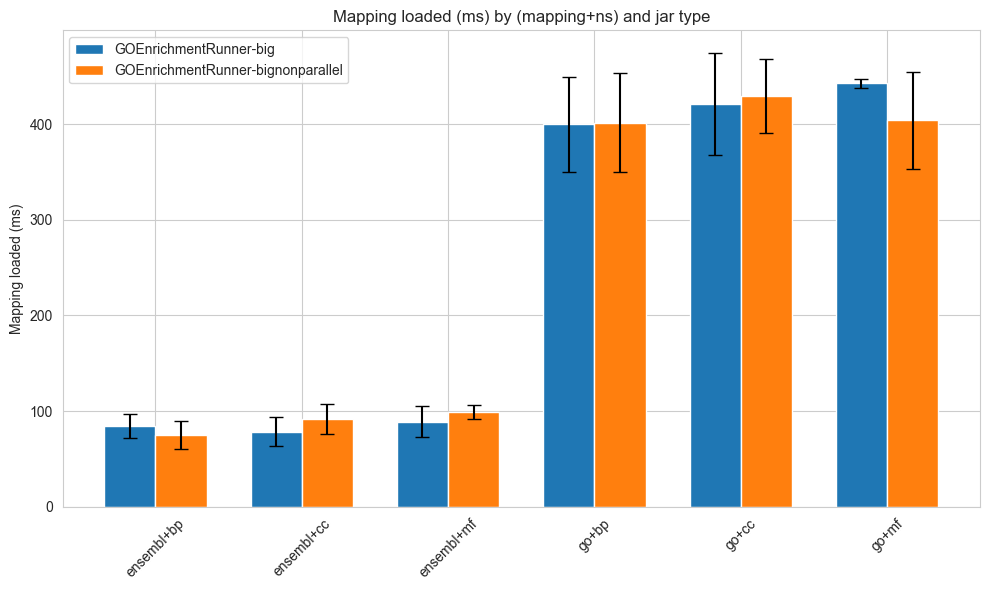

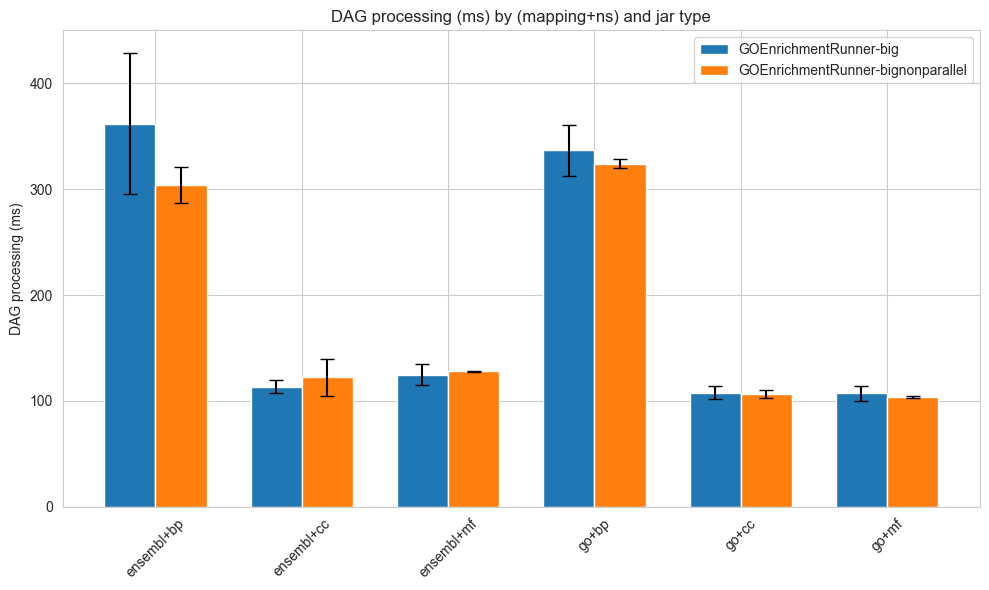

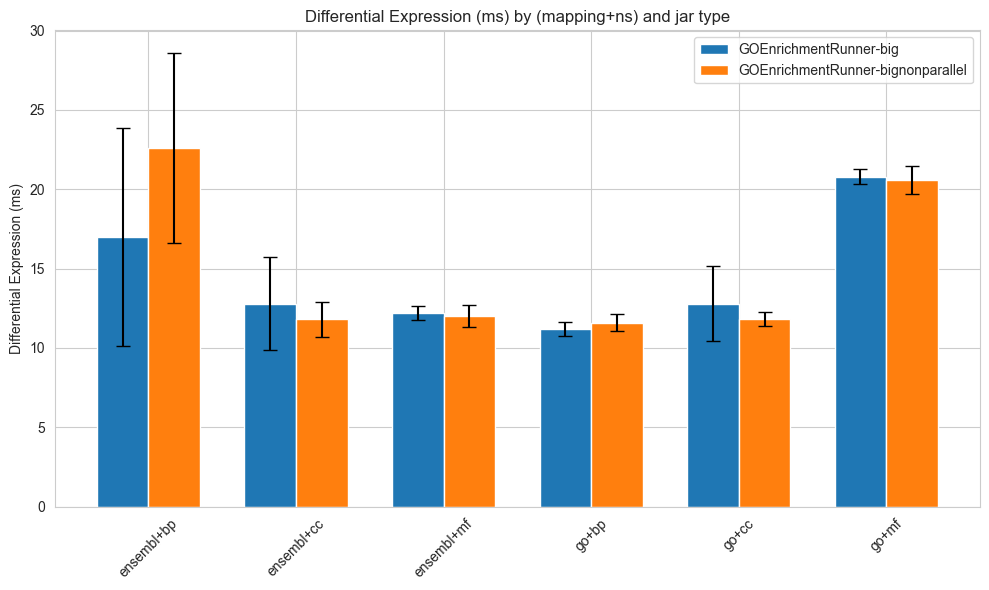

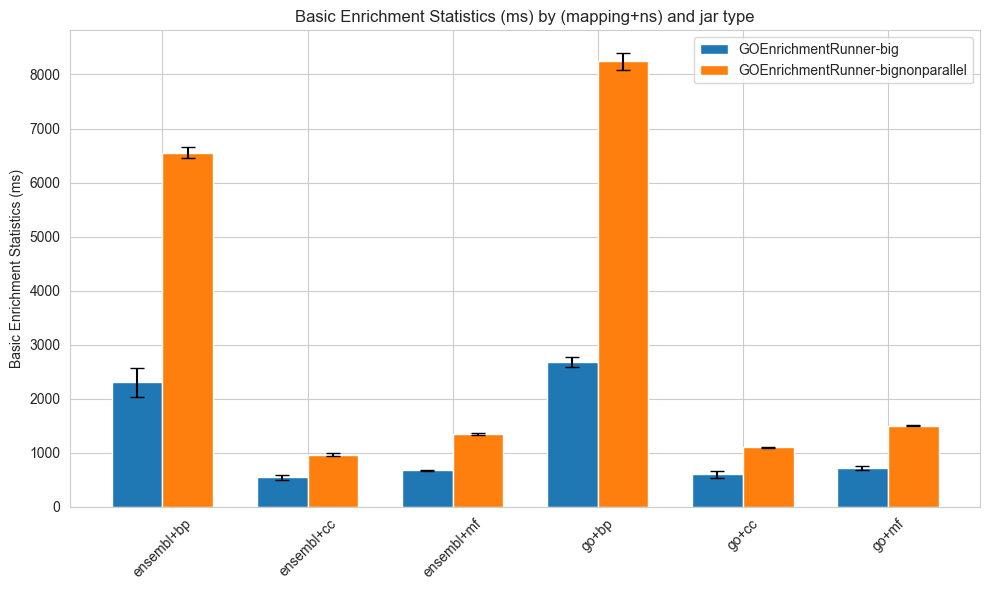

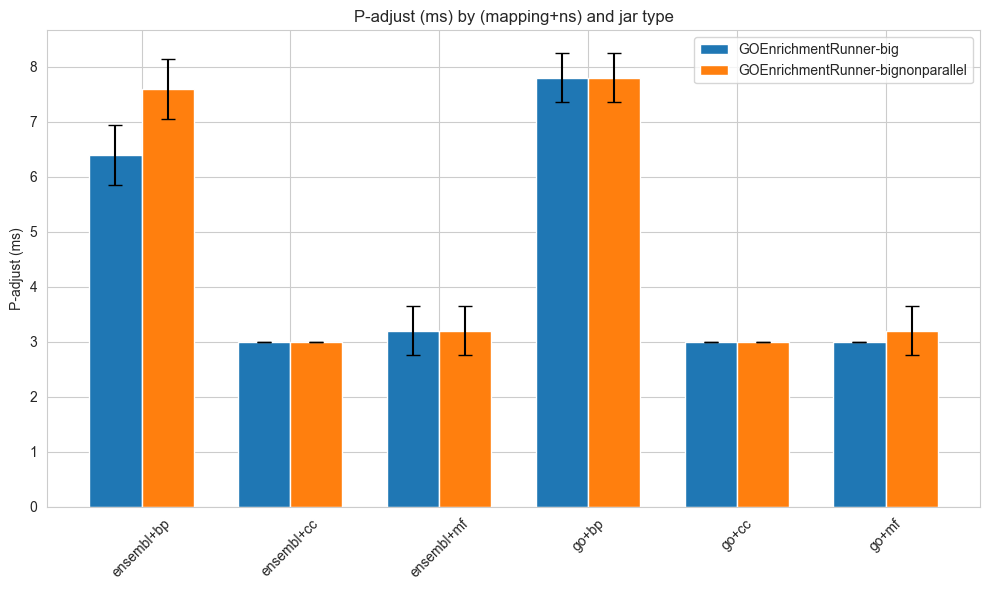

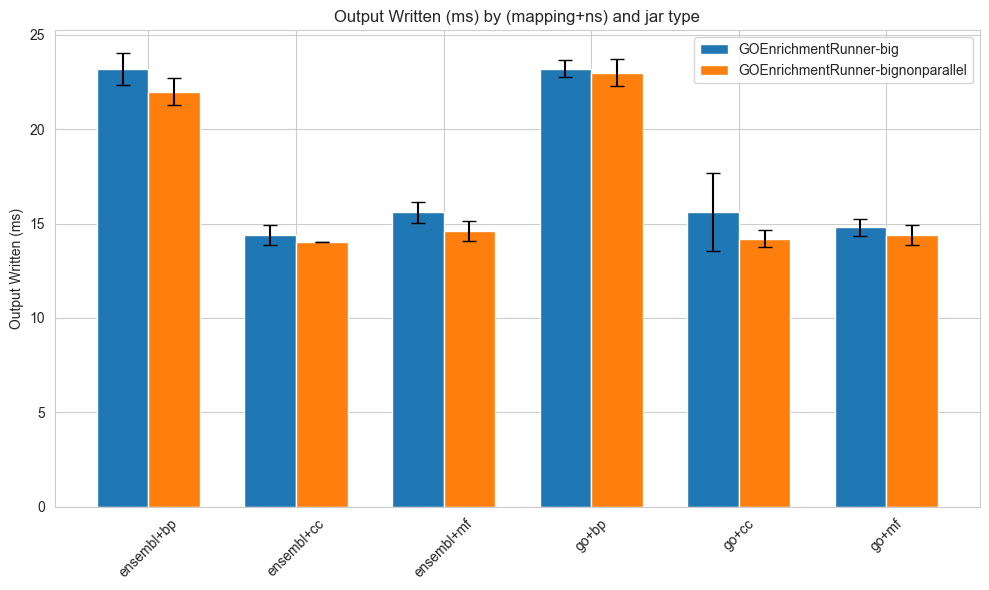

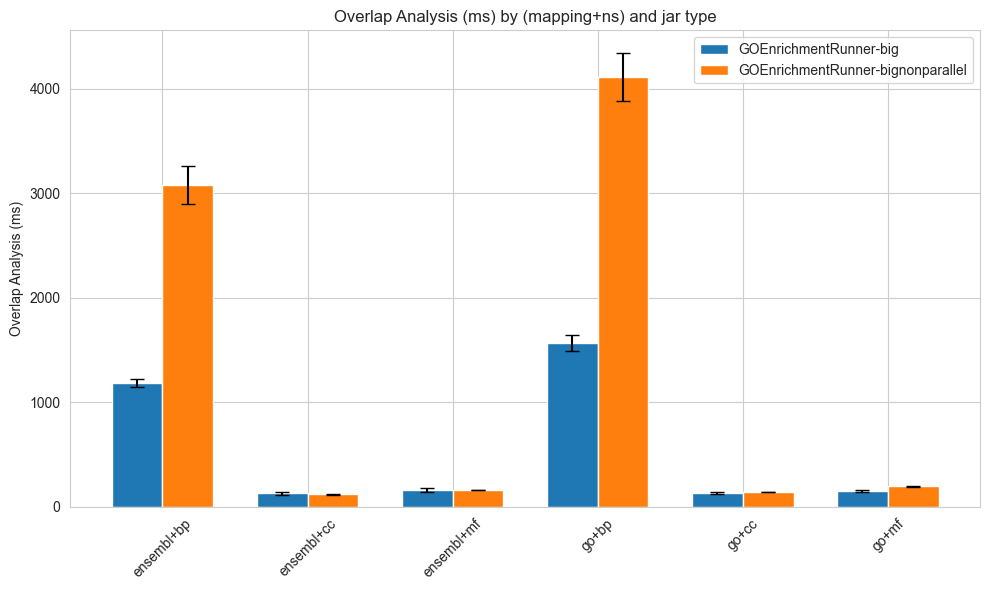

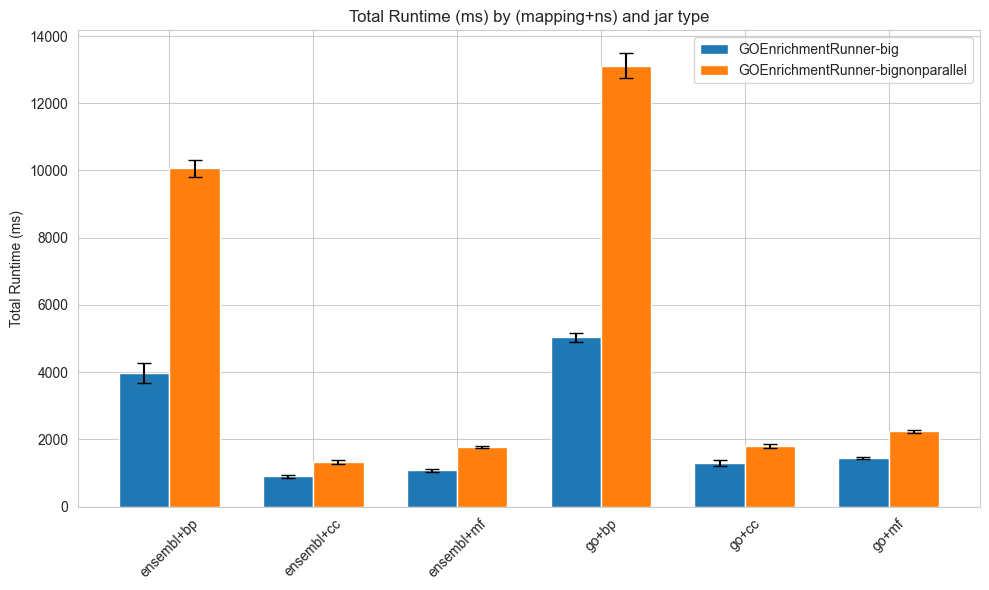

In [54]:

for cat, label in categories.items():
    plot_category(cat, ylabel=label, title=f"{label} by (mapping+ns) and jar type")

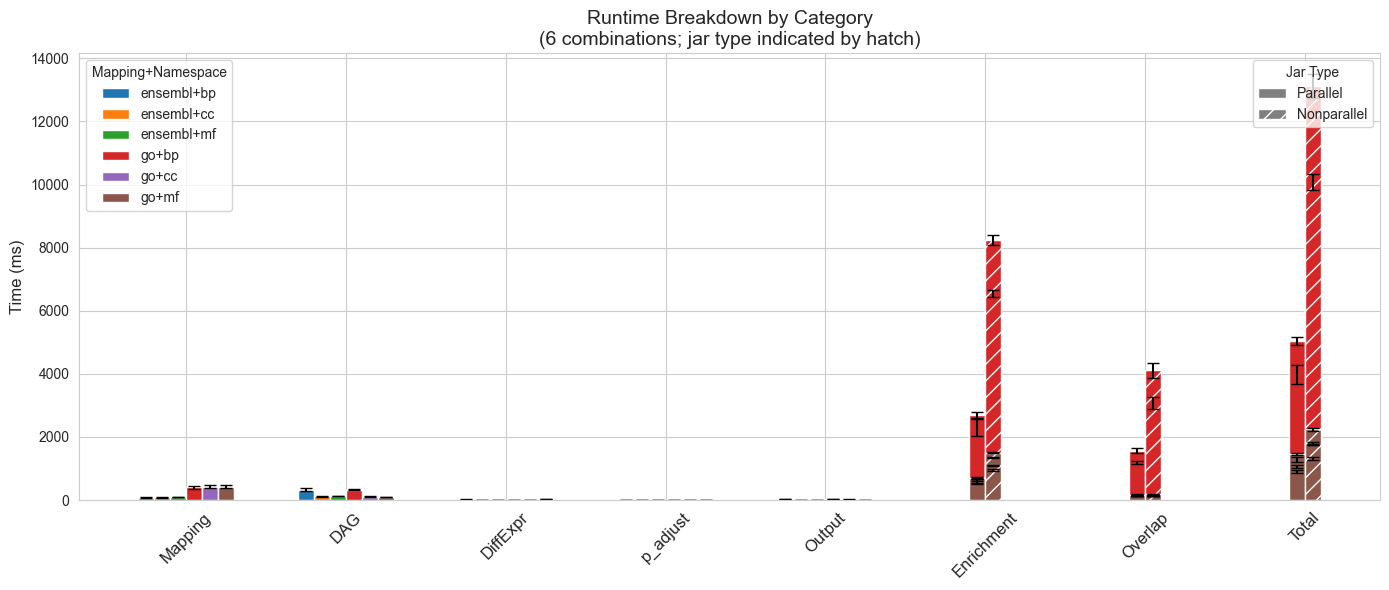

In [55]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib inline

# =============================================================================
# Step 0. (Assumption) We already have a DataFrame 'df' that was built
# from parsing the log files. It must contain at least the following columns:
#
#   mapping, ns, jar, Mapping, DAG, DiffExpr, Enrichment, p_adjust,
#   Output, Overlap, Total
#
# Also, add a column 'comb' to represent the combination of mapping and ns.
# =============================================================================
df['comb'] = df['mapping'] + "+" + df['ns']
combinations = sorted(df['comb'].unique())  # e.g. ["ensembl+bp", "ensembl+cc", "ensembl+mf", "go+bp", "go+cc", "go+mf"]
n_comb = len(combinations)

# Define which jar names correspond to which jar type.
jar_mapping = {
    "GOEnrichmentRunner-big": "parallel",
    "GOEnrichmentRunner-bignonparallel": "nonparallel"
}

# Map the jar column to a simplified jar type.
df['jar_type'] = df['jar'].map(jar_mapping)

# =============================================================================
# Step 1. Aggregate the timing metrics.
# We separate the metrics into two groups:
#
#   A. Common metrics (aggregated over jar type):
#         "Mapping", "DAG", "DiffExpr", "p_adjust", "Output"
#
#   B. Jar-specific metrics (for which we want separate values for
#      parallel and nonparallel):
#         "Enrichment", "Overlap", "Total"
#
# (Feel free to adjust the lists below.)
# =============================================================================
common_metrics = ["Mapping", "DAG", "DiffExpr", "p_adjust", "Output"]
jar_metrics = ["Enrichment", "Overlap", "Total"]

# (A) Compute aggregated stats for common metrics (grouped by combination):
common_stats = {}  # keys will be metric names, values DataFrames indexed by comb with columns ['mean','std']
for metric in common_metrics:
    grp = df.groupby('comb')[metric].agg(['mean', 'std'])
    common_stats[metric] = grp

# (B) For jar-specific metrics, compute stats per combination and jar_type.
jar_stats = {}  # keys will be metric names; values will be DataFrames with a MultiIndex columns: ('mean', jar_type) and ('std', jar_type)
for metric in jar_metrics:
    rows = []
    for comb in combinations:
        for jar_type in ['parallel', 'nonparallel']:
            sub = df[(df['comb'] == comb) & (df['jar_type'] == jar_type)]
            if len(sub) > 0:
                m_val = sub[metric].mean()
                s_val = sub[metric].std()
            else:
                m_val = np.nan
                s_val = np.nan
            rows.append({'comb': comb, 'jar': jar_type, 'mean': m_val, 'std': s_val})
    # Convert to DataFrame and pivot so that index is 'comb' and columns is a MultiIndex (first level: 'mean' and 'std', second level: jar type)
    tmp = pd.DataFrame(rows)
    tmp_pivot = tmp.pivot(index='comb', columns='jar')
    jar_stats[metric] = tmp_pivot

# =============================================================================
# Step 2. Build one grouped bar plot.
#
# The x-axis groups will be each timing metric (in the order):
#   common_metrics (one bar per combination) then jar_metrics (two bars per combination)
#
# For each common metric we plot 6 bars (one per combination), and for each jar-specific metric we plot 2 bars
# per combination (one for parallel and one for nonparallel). Colors indicate the combination (mapping+ns)
# and hatch distinguishes jar type (solid for parallel, hatched for nonparallel).
# =============================================================================

# Define the overall ordering of categories (x-axis groups)
all_categories = common_metrics + jar_metrics
n_groups = len(all_categories)

# We'll assign each combination (mapping+ns) a distinct color.
colors = [plt.cm.tab10(i) for i in range(n_comb)]

# We'll now define the x-axis positions for each group.
group_positions = np.arange(n_groups)

# For common metrics: in each group we want one bar per combination.
bar_width_common = 0.1
offsets_common = (np.arange(n_comb) - (n_comb - 1) / 2) * bar_width_common

# For jar-specific metrics: in each group we want two bars per combination.
bar_width_jar = 0.1
# For each combination, we need two positions: one for parallel and one for nonparallel.
offsets_jar = []
for i in range(n_comb):
    base = i * 2  # two positions per combination
    offsets_jar.append(-bar_width_jar / 2)  # for parallel
    offsets_jar.append(bar_width_jar / 2)  # for nonparallel
offsets_jar = np.array(offsets_jar)

fig, ax = plt.subplots(figsize=(14, 6))

# To record one handle per combination for the legend.
comb_handles = {}

# Loop over each timing category (x-axis groups)
for j, cat in enumerate(all_categories):
    if cat in common_metrics:
        # For common metrics, one bar per combination.
        for i, comb in enumerate(combinations):
            pos = group_positions[j] + offsets_common[i]
            mean_val = common_stats[cat].loc[comb, 'mean']
            std_val = common_stats[cat].loc[comb, 'std']
            bar = ax.bar(pos, mean_val, bar_width_common, yerr=std_val,
                         color=colors[i], capsize=4)
            # Record one handle per combination (only once).
            if comb not in comb_handles:
                comb_handles[comb] = bar
    else:
        # For jar-specific metrics, there are two bars per combination.
        # We'll use our manually computed jar_stats.
        # The DataFrame for this metric has a MultiIndex column: first level 'mean' or 'std', second level 'parallel' or 'nonparallel'.
        for i, comb in enumerate(combinations):
            # Compute positions for parallel and nonparallel bars.
            # Here we assume that for each combination we have exactly 2 bars in the order: parallel then nonparallel.
            pos_parallel = group_positions[j] + offsets_jar[2 * i]
            pos_non = group_positions[j] + offsets_jar[2 * i + 1]
            # Use .loc to extract the values. If data is missing, use np.nan.
            try:
                mean_parallel = jar_stats[cat].loc[comb, ('mean', 'parallel')]
                std_parallel = jar_stats[cat].loc[comb, ('std', 'parallel')]
            except KeyError:
                mean_parallel = np.nan
                std_parallel = np.nan
            try:
                mean_non = jar_stats[cat].loc[comb, ('mean', 'nonparallel')]
                std_non = jar_stats[cat].loc[comb, ('std', 'nonparallel')]
            except KeyError:
                mean_non = np.nan
                std_non = np.nan
            # Plot parallel (solid fill) and nonparallel (hatch) bars.
            bar_parallel = ax.bar(pos_parallel, mean_parallel, bar_width_jar,
                                  yerr=std_parallel, color=colors[i], capsize=4)
            bar_non = ax.bar(pos_non, mean_non, bar_width_jar,
                             yerr=std_non, color=colors[i], capsize=4, hatch='//')
            if comb not in comb_handles:
                comb_handles[comb] = bar_parallel

# Set x-axis tick labels to the metric names.
ax.set_xticks(group_positions)
ax.set_xticklabels(all_categories, rotation=45, fontsize=12)
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("Runtime Breakdown by Category\n(6 combinations; jar type indicated by hatch)", fontsize=14)

# Create a legend for the 6 combinations (colors)
legend1 = ax.legend(comb_handles.values(), comb_handles.keys(), title="Mapping+Namespace", loc="upper left")

# Create a custom legend to explain the hatch pattern.
legend_elements = [Patch(facecolor='gray', label='Parallel'),
                   Patch(facecolor='gray', hatch='//', label='Nonparallel')]
legend2 = ax.legend(handles=legend_elements, title="Jar Type", loc="upper right")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

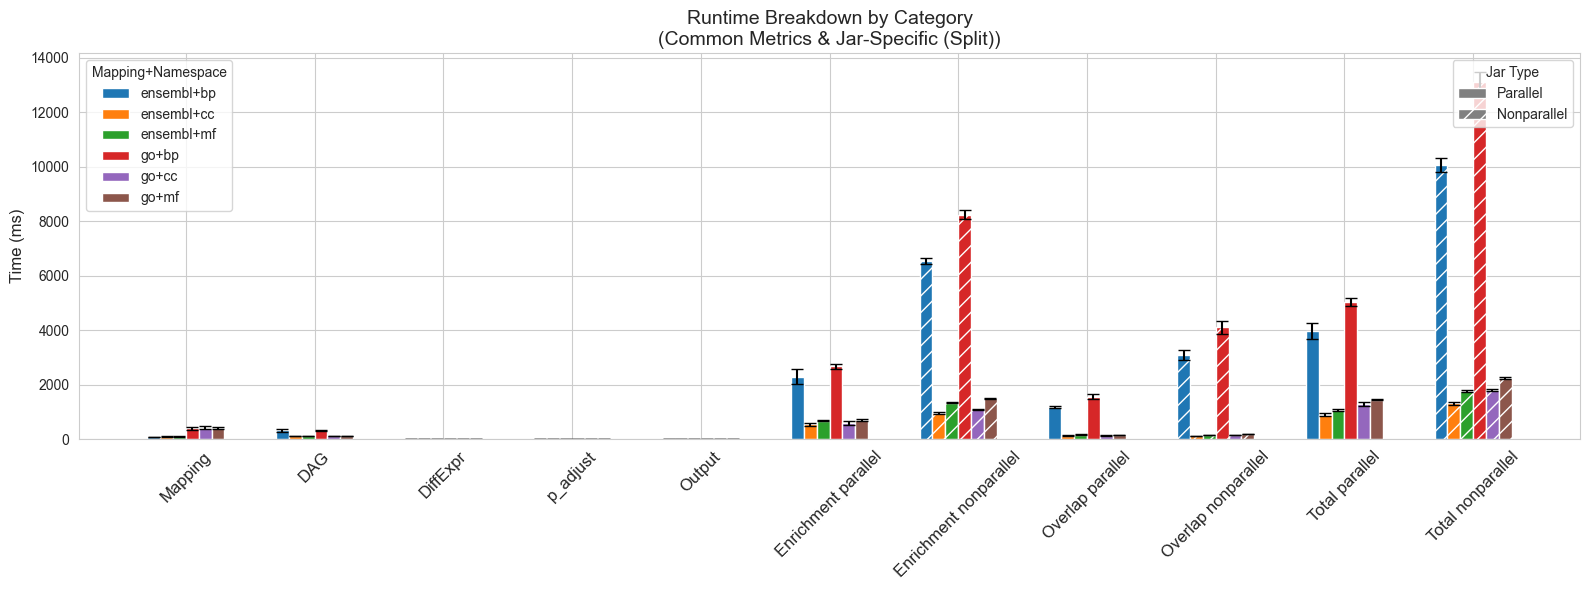

In [56]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib inline

# --- Assumptions and Preparations ---
# Assume df has already been built from your logs.
# It must contain at least:
#   mapping, ns, jar, Mapping, DAG, DiffExpr, Enrichment, p_adjust, Output, Overlap, Total

# Create a combination label (e.g. "go+bp", "ensembl+mf", etc.)
df['comb'] = df['mapping'] + "+" + df['ns']
combinations = sorted(df['comb'].unique())  # Should be 6 combinations
n_comb = len(combinations)

# Map the jar names to simpler jar types.
jar_mapping = {
    "GOEnrichmentRunner-big": "parallel",
    "GOEnrichmentRunner-bignonparallel": "nonparallel"
}
df['jar_type'] = df['jar'].map(jar_mapping)

# Define the metric groups.
common_metrics = ["Mapping", "DAG", "DiffExpr", "p_adjust", "Output"]
jar_metrics = ["Enrichment", "Overlap", "Total"]

# --- Aggregate the Data ---
# For the common metrics, compute stats grouped by combination.
common_stats = {}
for metric in common_metrics:
    grp = df.groupby('comb')[metric].agg(['mean', 'std'])
    common_stats[metric] = grp

# For the jar-specific metrics, compute stats per combination and jar_type.
jar_stats = {}
for metric in jar_metrics:
    rows = []
    for comb in combinations:
        for jar_type in ['parallel', 'nonparallel']:
            sub = df[(df['comb'] == comb) & (df['jar_type'] == jar_type)]
            if len(sub) > 0:
                m_val = sub[metric].mean()
                s_val = sub[metric].std()
            else:
                m_val = np.nan
                s_val = np.nan
            rows.append({'comb': comb, 'jar': jar_type, 'mean': m_val, 'std': s_val})
    tmp = pd.DataFrame(rows)
    tmp_pivot = tmp.pivot(index='comb', columns='jar')
    jar_stats[metric] = tmp_pivot

# --- Define X-Axis Groups ---
# For common metrics, the group labels remain unchanged.
common_categories = common_metrics
# For jar-specific metrics, we create two groups per metric.
jar_categories = []
for metric in jar_metrics:
    for jar_type in ['parallel', 'nonparallel']:
        jar_categories.append(f"{metric} {jar_type}")

# Overall x-axis groups:
all_categories = common_categories + jar_categories
n_groups = len(all_categories)

# --- Plotting Setup ---
# Set positions for groups on the x-axis.
group_positions = np.arange(n_groups)
# Within each group, plot 6 bars (one per combination).
bar_width = 0.1
offsets = (np.arange(n_comb) - (n_comb - 1) / 2) * bar_width

# Define distinct colors for each combination.
colors = [plt.cm.tab10(i) for i in range(n_comb)]

fig, ax = plt.subplots(figsize=(16, 6))
# To collect one handle per combination (for the legend)
comb_handles = {}

# --- Plot Each Group ---
for j, cat_label in enumerate(all_categories):
    if j < len(common_categories):
        # This group corresponds to a common metric.
        metric = cat_label  # e.g., "Mapping"
        for i, comb in enumerate(combinations):
            pos = group_positions[j] + offsets[i]
            mean_val = common_stats[metric].loc[comb, 'mean']
            std_val = common_stats[metric].loc[comb, 'std']
            bar = ax.bar(pos, mean_val, bar_width, yerr=std_val,
                         color=colors[i], capsize=4)
            if comb not in comb_handles:
                comb_handles[comb] = bar
    else:
        # This group corresponds to a jar-specific metric.
        # The label is something like "Enrichment parallel"
        parts = cat_label.split()
        metric = parts[0]  # e.g., "Enrichment"
        jar_type = parts[1]  # e.g., "parallel" or "nonparallel"
        for i, comb in enumerate(combinations):
            pos = group_positions[j] + offsets[i]
            try:
                mean_val = jar_stats[metric].loc[comb, ('mean', jar_type)]
                std_val = jar_stats[metric].loc[comb, ('std', jar_type)]
            except KeyError:
                mean_val = np.nan
                std_val = np.nan
            bar = ax.bar(pos, mean_val, bar_width, yerr=std_val,
                         color=colors[i], capsize=4)
            # For nonparallel bars, add hatch.
            if jar_type == "nonparallel":
                # Note: hatch must be set on each Rectangle.
                for rect in bar:
                    rect.set_hatch("//")
            if comb not in comb_handles:
                comb_handles[comb] = bar

# --- Finalize the Plot ---
ax.set_xticks(group_positions)
ax.set_xticklabels(all_categories, rotation=45, fontsize=12)
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("Runtime Breakdown by Category\n(Common Metrics & Jar-Specific (Split))", fontsize=14)

# Legend for the combination colors.
legend1 = ax.legend(comb_handles.values(), comb_handles.keys(), title="Mapping+Namespace", loc="upper left")
# Custom legend for jar type.
legend_elements = [Patch(facecolor='gray', label='Parallel'),
                   Patch(facecolor='gray', hatch='//', label='Nonparallel')]
legend2 = ax.legend(handles=legend_elements, title="Jar Type", loc="upper right")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

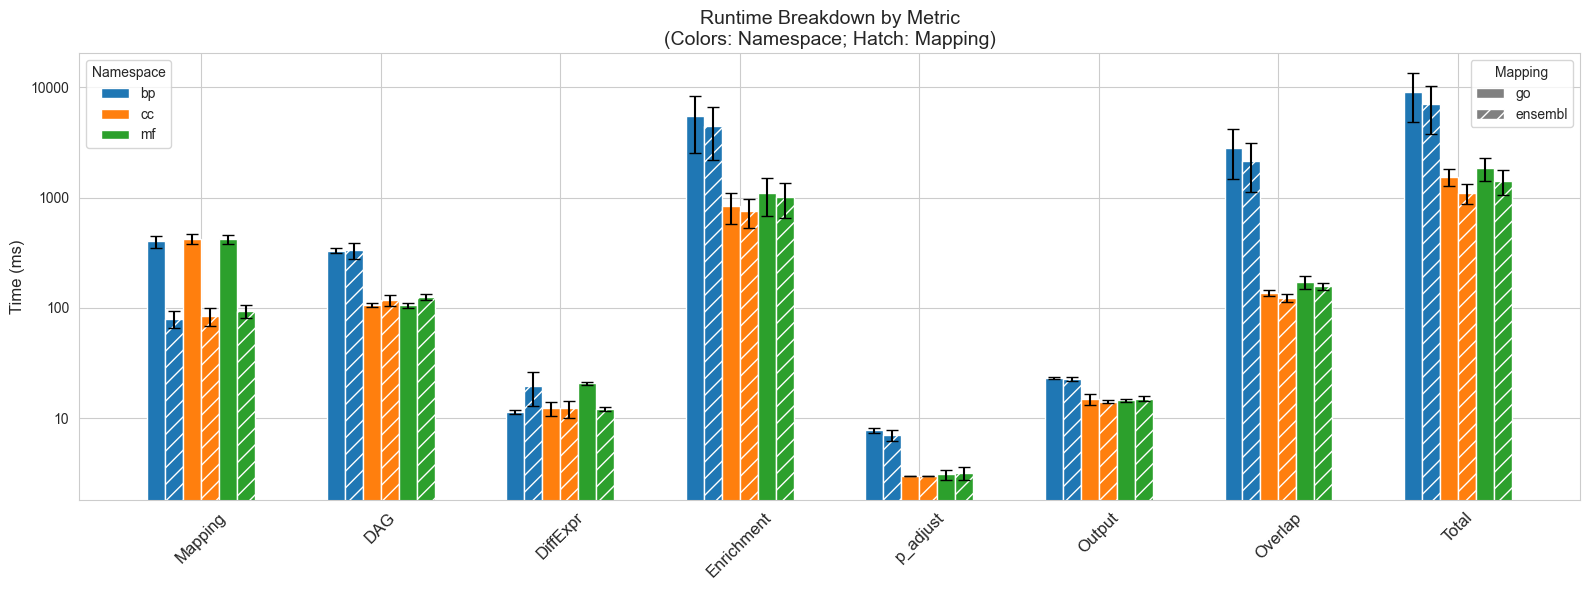

In [57]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Patch

%matplotlib inline

# ----------------------------------------------------------------------
# Assumptions and Data Aggregation
# ----------------------------------------------------------------------
# Assume df is already available and has at least:
#   "mapping", "ns", "Mapping", "DAG", "DiffExpr", "Enrichment",
#   "p_adjust", "Output", "Overlap", and "Total"
#
# We want to plot the following metric categories:
metrics = ["Mapping", "DAG", "DiffExpr", "Enrichment", "p_adjust", "Output", "Overlap", "Total"]

# Aggregate the timing data by both mapping and ns.
# This creates, for each metric, a DataFrame indexed by a MultiIndex (mapping, ns)
stats = {}
for metric in metrics:
    grp = df.groupby(['mapping', 'ns'])[metric].agg(['mean', 'std'])
    stats[metric] = grp

# ----------------------------------------------------------------------
# Define the Order and Visual Appearance
# ----------------------------------------------------------------------
# We want to show 6 bars per metric corresponding to the two mapping types ("go" and "ensembl")
# for each of the 3 namespaces. The color will depend only on the namespace, and the hatch will
# indicate the mapping type.
#
# Define the desired ordering: for each namespace, show "go" then "ensembl".
# (This gives 3*2 = 6 groups per metric.)
namespaces = sorted(df['ns'].unique())  # e.g., ['bp', 'cc', 'mf']
ordered_groups = []
for ns in namespaces:
    for mapping in ["go", "ensembl"]:
        ordered_groups.append((mapping, ns))
n_groups = len(ordered_groups)  # should be 6

# Create a color mapping for namespaces (3 colors)
color_map = {}
color_options = plt.cm.tab10.colors  # using the first few colors from tab10
for i, ns in enumerate(namespaces):
    color_map[ns] = color_options[i]

# Define hatch mapping for mapping type.
# Here we choose no hatch for "go" and a hatch pattern for "ensembl".
hatch_map = {
    "go": "",  # no hatch for go
    "ensembl": "//"  # hatch for ensembl
}

# ----------------------------------------------------------------------
# Plotting Setup
# ----------------------------------------------------------------------
n_metrics = len(metrics)  # number of x-axis groups (one per metric)
group_positions = np.arange(n_metrics)
bar_width = 0.1
# Within each group, position the 6 bars side-by-side.
offsets = (np.arange(n_groups) - (n_groups - 1) / 2) * bar_width

fig, ax = plt.subplots(figsize=(16, 6))

# For constructing legends, we collect one representative bar per namespace and mapping type.
ns_handles = {}
mapping_handles = {}

# ----------------------------------------------------------------------
# Plot Each Metric Group
# ----------------------------------------------------------------------
for j, metric in enumerate(metrics):
    # For each combination (mapping, ns) in our desired order, plot one bar.
    for i, (mapping, ns) in enumerate(ordered_groups):
        pos = group_positions[j] + offsets[i]
        try:
            mean_val = stats[metric].loc[(mapping, ns)]['mean']
            std_val = stats[metric].loc[(mapping, ns)]['std']
        except KeyError:
            mean_val, std_val = np.nan, np.nan
        bar = ax.bar(pos, mean_val, bar_width, yerr=std_val,
                     color=color_map[ns],
                     hatch=hatch_map[mapping],
                     capsize=4)
        # Record one bar per namespace (for color legend)
        if ns not in ns_handles:
            ns_handles[ns] = bar
        # Record one bar per mapping type (for hatch legend)
        if mapping not in mapping_handles:
            mapping_handles[mapping] = bar

# ----------------------------------------------------------------------
# Finalize the Plot
# ----------------------------------------------------------------------
ax.set_xticks(group_positions)
ax.set_xticklabels(metrics, rotation=45, fontsize=12)
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("Runtime Breakdown by Metric\n(Colors: Namespace; Hatch: Mapping)", fontsize=14)

# Set the y-axis to log scale with tick labels like 1, 10, 100, etc.
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

# Create legend for namespace colors.
ns_legend = ax.legend([ns_handles[ns] for ns in namespaces],
                      [ns for ns in namespaces],
                      title="Namespace",
                      loc="upper left")

# Create custom legend for mapping types (hatch).
mapping_patches = []
for mapping in ["go", "ensembl"]:
    patch = Patch(facecolor='gray', hatch=hatch_map[mapping] if hatch_map[mapping] else None, label=mapping)
    mapping_patches.append(patch)
mapping_legend = ax.legend(handles=mapping_patches, title="Mapping", loc="upper right")
ax.add_artist(ns_legend)

plt.tight_layout()
plt.show()

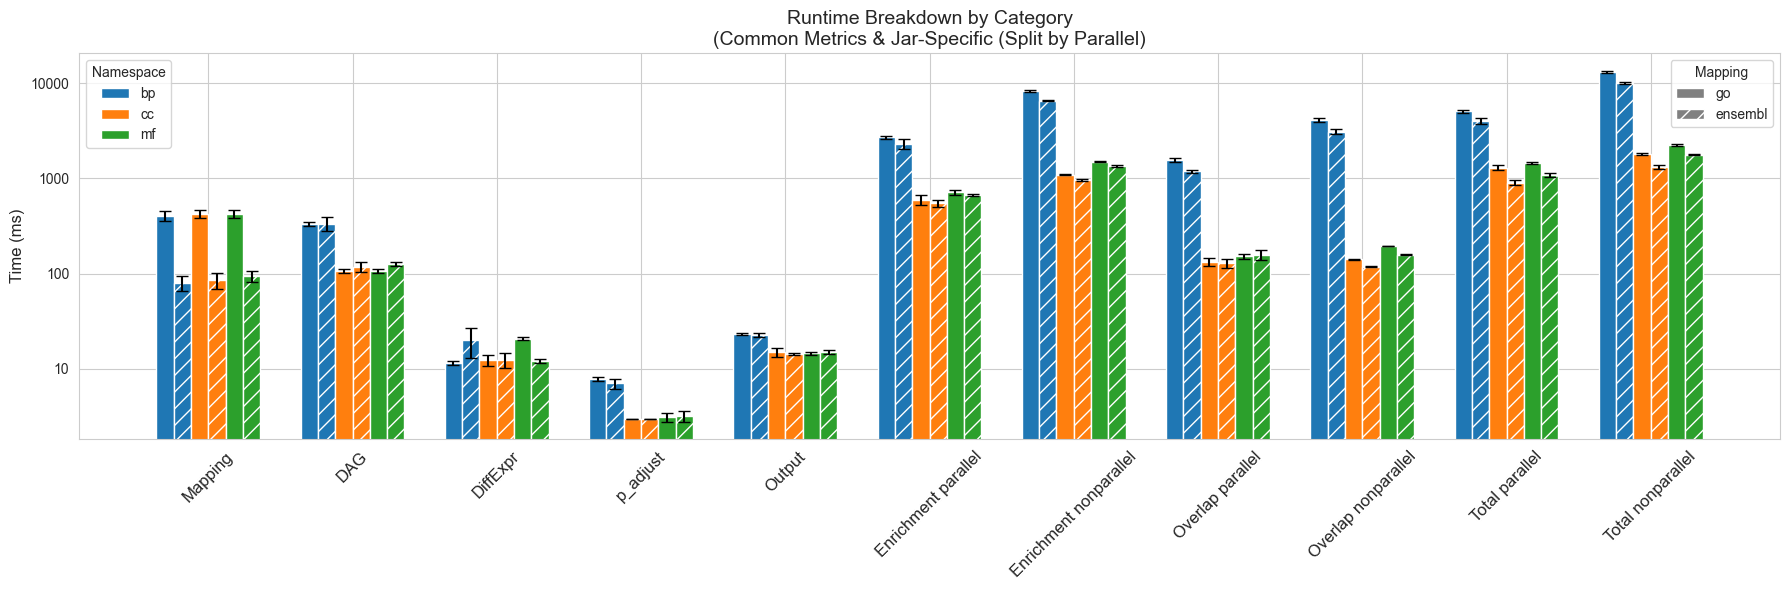

In [58]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Patch

%matplotlib inline

# ----------------------------------------------------------------------
# Assumptions & Data Preparation
# ----------------------------------------------------------------------
# We assume that df is already available and contains at least:
#   "mapping", "ns", "jar", "Mapping", "DAG", "DiffExpr",
#   "Enrichment", "p_adjust", "Output", "Overlap", and "Total"

# Create a column for jar type (only used for jar-specific metrics)
jar_mapping = {
    "GOEnrichmentRunner-big": "parallel",
    "GOEnrichmentRunner-bignonparallel": "nonparallel"
}
df['jar_type'] = df['jar'].map(jar_mapping)

# Define orders.
# We want to collapse the 6 combinations (originally 3 namespaces x 2 mappings)
# into 3 colors (one per namespace) with hatch distinguishing the mapping.
# Define the desired order for namespaces and mapping types:
ns_order = ["bp", "cc", "mf"]  # three namespaces (adjust as needed)
mapping_order = ["go", "ensembl"]  # two mapping types

# Create an ordered list of (mapping, ns) combinations.
ordered_combinations = []
for ns in ns_order:
    for mapping in mapping_order:
        ordered_combinations.append((mapping, ns))
# This yields 6 entries, in the order:
#   (go, bp), (ensembl, bp), (go, cc), (ensembl, cc), (go, mf), (ensembl, mf)

# Define color mapping for namespaces (3 colors)
color_map = {
    "bp": "tab:blue",
    "cc": "tab:orange",
    "mf": "tab:green"
}

# Define hatch mapping for mapping types.
hatch_map = {
    "go": "",  # no hatch for "go"
    "ensembl": "//"  # hatch for "ensembl"
}

# ----------------------------------------------------------------------
# Aggregate the Timing Metrics
# ----------------------------------------------------------------------
# Define metric groups.
# Common metrics: aggregated ignoring jar type.
common_metrics = ["Mapping", "DAG", "DiffExpr", "p_adjust", "Output"]
# Jar-specific metrics: aggregated separately by jar type.
jar_metrics = ["Enrichment", "Overlap", "Total"]

# (A) Aggregate common metrics by (mapping, ns)
stats_common = {}
for metric in common_metrics:
    stats_common[metric] = df.groupby(['mapping', 'ns'])[metric].agg(['mean', 'std'])

# (B) Aggregate jar-specific metrics by (mapping, ns, jar_type)
stats_jar = {}
for metric in jar_metrics:
    stats_jar[metric] = df.groupby(['mapping', 'ns', 'jar_type'])[metric].agg(['mean', 'std'])

# ----------------------------------------------------------------------
# Define the X-Axis Groups for the Plot
# ----------------------------------------------------------------------
# For common metrics, the group labels are the metric names.
common_categories = common_metrics  # 5 groups

# For jar-specific metrics, we create two groups per metric (parallel and nonparallel).
jar_categories = []
for metric in jar_metrics:
    for jt in ["parallel", "nonparallel"]:
        jar_categories.append(f"{metric} {jt}")
# Total jar-specific groups = 3 metrics * 2 = 6 groups

# All x-axis groups (in order):
all_categories = common_categories + jar_categories  # total 5 + 6 = 11 groups
n_groups = len(all_categories)  # should be 11
group_positions = np.arange(n_groups)

# ----------------------------------------------------------------------
# Plotting Setup
# ----------------------------------------------------------------------
# Within each x-axis group, we want to plot 6 bars (one per (mapping, ns) combination).
# We set fixed positions (offsets) for these 6 bars.
# We'll define an offsets array so that the 6 bars are centered around the group's center.
bar_width = 0.12
# For 6 bars, we can use offsets such as: [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5] * bar_width.
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * bar_width

fig, ax = plt.subplots(figsize=(18, 6))

# We'll also prepare dictionaries for legend handles.
ns_handles = {}  # for namespace colors
mapping_handles = {}  # for mapping type (hatch)

# ----------------------------------------------------------------------
# Plot Each X-Axis Group
# ----------------------------------------------------------------------
for j, group_label in enumerate(all_categories):
    # Determine whether this group is common or jar-specific.
    if j < len(common_categories):
        # This is a common metric.
        metric = common_categories[j]
        # For common metrics, use stats_common (grouped by (mapping, ns))
        for i, (mapping, ns) in enumerate(ordered_combinations):
            pos = group_positions[j] + offsets[i]
            try:
                mean_val = stats_common[metric].loc[(mapping, ns)]['mean']
                std_val = stats_common[metric].loc[(mapping, ns)]['std']
            except KeyError:
                mean_val, std_val = np.nan, np.nan
            bar = ax.bar(pos, mean_val, bar_width, yerr=std_val,
                         color=color_map[ns],
                         hatch=hatch_map[mapping],
                         capsize=4)
            # Record one handle per namespace for the color legend.
            if ns not in ns_handles:
                ns_handles[ns] = bar
            # Record one handle per mapping for the hatch legend.
            if mapping not in mapping_handles:
                mapping_handles[mapping] = bar
    else:
        # This is a jar-specific metric.
        # Determine which metric and which jar type.
        # The jar-specific groups start at index len(common_categories).
        idx = j - len(common_categories)
        # There are 2 groups per jar-specific metric.
        metric_idx = idx // 2  # which metric (0, 1, or 2)
        jt = "parallel" if (idx % 2 == 0) else "nonparallel"
        metric = jar_metrics[metric_idx]
        # Use stats_jar (grouped by (mapping, ns, jar_type))
        for i, (mapping, ns) in enumerate(ordered_combinations):
            pos = group_positions[j] + offsets[i]
            try:
                mean_val = stats_jar[metric].loc[(mapping, ns, jt)]['mean']
                std_val = stats_jar[metric].loc[(mapping, ns, jt)]['std']
            except KeyError:
                mean_val, std_val = np.nan, np.nan
            bar = ax.bar(pos, mean_val, bar_width, yerr=std_val,
                         color=color_map[ns],
                         hatch=hatch_map[mapping],
                         capsize=4)
            if ns not in ns_handles:
                ns_handles[ns] = bar
            if mapping not in mapping_handles:
                mapping_handles[mapping] = bar

# ----------------------------------------------------------------------
# Finalize the Plot
# ----------------------------------------------------------------------
ax.set_xticks(group_positions)
ax.set_xticklabels(all_categories, rotation=45, fontsize=12)
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("Runtime Breakdown by Category\n(Common Metrics & Jar-Specific (Split by Parallel)", fontsize=14)

# Set y-axis to log scale with tick labels like 1, 10, 100.
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

# Create legend for namespaces (colors)
ns_legend = ax.legend([ns_handles[ns] for ns in ns_order],
                      [ns for ns in ns_order],
                      title="Namespace",
                      loc="upper left")
# Create custom legend for mapping types (hatch)
mapping_patches = []
for m in mapping_order:
    # Use a representative patch.
    patch = Patch(facecolor='gray', hatch=hatch_map[m] if hatch_map[m] else None, label=m)
    mapping_patches.append(patch)
mapping_legend = ax.legend(handles=mapping_patches, title="Mapping", loc="upper right")
ax.add_artist(ns_legend)

plt.tight_layout()
plt.show()

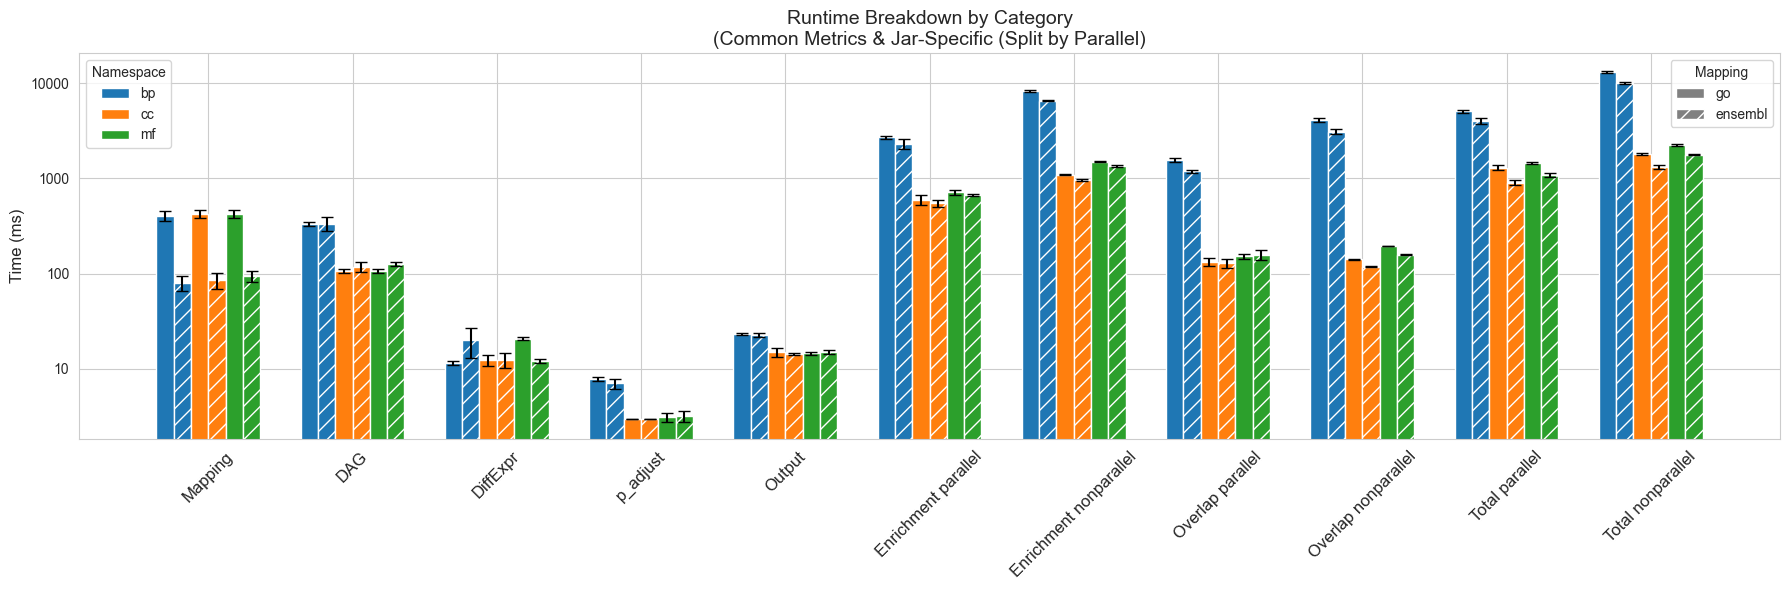

In [59]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Patch

%matplotlib inline

# ----------------------------------------------------------------------
# Assumptions & Data Preparation
# ----------------------------------------------------------------------
# We assume that df is already available and contains at least:
#   "mapping", "ns", "jar", "Mapping", "DAG", "DiffExpr",
#   "Enrichment", "p_adjust", "Output", "Overlap", and "Total"

# Create a column for jar type (only used for jar-specific metrics)
jar_mapping = {
    "GOEnrichmentRunner-big": "parallel",
    "GOEnrichmentRunner-bignonparallel": "nonparallel"
}
df['jar_type'] = df['jar'].map(jar_mapping)

# Define orders.
# We want to collapse the 6 combinations (originally 3 namespaces x 2 mappings)
# into 3 colors (one per namespace) with hatch distinguishing the mapping.
# Define the desired order for namespaces and mapping types:
ns_order = ["bp", "cc", "mf"]  # three namespaces (adjust as needed)
mapping_order = ["go", "ensembl"]  # two mapping types

# Create an ordered list of (mapping, ns) combinations.
ordered_combinations = []
for ns in ns_order:
    for mapping in mapping_order:
        ordered_combinations.append((mapping, ns))
# This yields 6 entries, in the order:
#   (go, bp), (ensembl, bp), (go, cc), (ensembl, cc), (go, mf), (ensembl, mf)

# Define color mapping for namespaces (3 colors)
color_map = {
    "bp": "tab:blue",
    "cc": "tab:orange",
    "mf": "tab:green"
}

# Define hatch mapping for mapping types.
hatch_map = {
    "go": "",  # no hatch for "go"
    "ensembl": "//"  # hatch for "ensembl"
}

# ----------------------------------------------------------------------
# Aggregate the Timing Metrics
# ----------------------------------------------------------------------
# Define metric groups.
# Common metrics: aggregated ignoring jar type.
common_metrics = ["Mapping", "DAG", "DiffExpr", "p_adjust", "Output"]
# Jar-specific metrics: aggregated separately by jar type.
jar_metrics = ["Enrichment", "Overlap", "Total"]

# (A) Aggregate common metrics by (mapping, ns)
stats_common = {}
for metric in common_metrics:
    stats_common[metric] = df.groupby(['mapping', 'ns'])[metric].agg(['mean', 'std'])

# (B) Aggregate jar-specific metrics by (mapping, ns, jar_type)
stats_jar = {}
for metric in jar_metrics:
    stats_jar[metric] = df.groupby(['mapping', 'ns', 'jar_type'])[metric].agg(['mean', 'std'])

# ----------------------------------------------------------------------
# Define the X-Axis Groups for the Plot
# ----------------------------------------------------------------------
# For common metrics, the group labels are the metric names.
common_categories = common_metrics  # 5 groups

# For jar-specific metrics, we create two groups per metric (parallel and nonparallel).
jar_categories = []
for metric in jar_metrics:
    for jt in ["parallel", "nonparallel"]:
        jar_categories.append(f"{metric} {jt}")
# Total jar-specific groups = 3 metrics * 2 = 6 groups

# All x-axis groups (in order):
all_categories = common_categories + jar_categories  # total 5 + 6 = 11 groups
n_groups = len(all_categories)  # should be 11
group_positions = np.arange(n_groups)

# ----------------------------------------------------------------------
# Plotting Setup
# ----------------------------------------------------------------------
# Within each x-axis group, we want to plot 6 bars (one per (mapping, ns) combination).
# We set fixed positions (offsets) for these 6 bars.
# We'll define an offsets array so that the 6 bars are centered around the group's center.
bar_width = 0.12
# For 6 bars, we can use offsets such as: [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5] * bar_width.
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * bar_width

fig, ax = plt.subplots(figsize=(18, 6))

# We'll also prepare dictionaries for legend handles.
ns_handles = {}  # for namespace colors
mapping_handles = {}  # for mapping type (hatch)

# ----------------------------------------------------------------------
# Plot Each X-Axis Group
# ----------------------------------------------------------------------
for j, group_label in enumerate(all_categories):
    # Determine whether this group is common or jar-specific.
    if j < len(common_categories):
        # This is a common metric.
        metric = common_categories[j]
        # For common metrics, use stats_common (grouped by (mapping, ns))
        for i, (mapping, ns) in enumerate(ordered_combinations):
            pos = group_positions[j] + offsets[i]
            try:
                mean_val = stats_common[metric].loc[(mapping, ns)]['mean']
                std_val = stats_common[metric].loc[(mapping, ns)]['std']
            except KeyError:
                mean_val, std_val = np.nan, np.nan
            bar = ax.bar(pos, mean_val, bar_width, yerr=std_val,
                         color=color_map[ns],
                         hatch=hatch_map[mapping],
                         capsize=4)
            # Record one handle per namespace for the color legend.
            if ns not in ns_handles:
                ns_handles[ns] = bar
            # Record one handle per mapping for the hatch legend.
            if mapping not in mapping_handles:
                mapping_handles[mapping] = bar
    else:
        # This is a jar-specific metric.
        # Determine which metric and which jar type.
        # The jar-specific groups start at index len(common_categories).
        idx = j - len(common_categories)
        # There are 2 groups per jar-specific metric.
        metric_idx = idx // 2  # which metric (0, 1, or 2)
        jt = "parallel" if (idx % 2 == 0) else "nonparallel"
        metric = jar_metrics[metric_idx]
        # Use stats_jar (grouped by (mapping, ns, jar_type))
        for i, (mapping, ns) in enumerate(ordered_combinations):
            pos = group_positions[j] + offsets[i]
            try:
                mean_val = stats_jar[metric].loc[(mapping, ns, jt)]['mean']
                std_val = stats_jar[metric].loc[(mapping, ns, jt)]['std']
            except KeyError:
                mean_val, std_val = np.nan, np.nan
            bar = ax.bar(pos, mean_val, bar_width, yerr=std_val,
                         color=color_map[ns],
                         hatch=hatch_map[mapping],
                         capsize=4)
            if ns not in ns_handles:
                ns_handles[ns] = bar
            if mapping not in mapping_handles:
                mapping_handles[mapping] = bar

# ----------------------------------------------------------------------
# Finalize the Plot
# ----------------------------------------------------------------------
ax.set_xticks(group_positions)
ax.set_xticklabels(all_categories, rotation=45, fontsize=12)
ax.set_ylabel("Time (ms)", fontsize=12)
ax.set_title("Runtime Breakdown by Category\n(Common Metrics & Jar-Specific (Split by Parallel)", fontsize=14)

# Set y-axis to log scale with tick labels like 1, 10, 100.
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

# Create legend for namespaces (colors)
ns_legend = ax.legend([ns_handles[ns] for ns in ns_order],
                      [ns for ns in ns_order],
                      title="Namespace",
                      loc="upper left")
# Create custom legend for mapping types (hatch)
mapping_patches = []
for m in mapping_order:
    # Use a representative patch.
    patch = Patch(facecolor='gray', hatch=hatch_map[m] if hatch_map[m] else None, label=m)
    mapping_patches.append(patch)
mapping_legend = ax.legend(handles=mapping_patches, title="Mapping", loc="upper right")
ax.add_artist(ns_legend)

plt.tight_layout()
plt.show()